In [ ]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import os
import time
import random
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from matplotlib import font_manager

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# CELL 3 — CONFIGURATION
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Image
IMG_SIZE = (224, 224)
NUM_CLASSES = 37

# Baseline training
BATCH_SIZE = 32
EPOCHS = 5

# Output directory
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Image size:", IMG_SIZE)
print("Classes:", NUM_CLASSES)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Image size: (224, 224)
Classes: 37
Batch size: 32
Epochs: 5


Image size: (224, 224)
Classes: 37
Batch size: 32
Epochs: 5

In [ ]:
# ============================================================
# CELL 4 — FONT + FIGURE SETTINGS
# ============================================================

ttf_files = [
    os.path.abspath(f)
    for f in os.listdir(".")
    if f.lower().endswith(".ttf")
]

if not ttf_files:
    raise FileNotFoundError(
        "No .ttf font file found in the root directory."
    )

times_fonts = [
    f for f in ttf_files
    if "times" in os.path.basename(f).lower()
]

FONT_PATH = times_fonts[0] if times_fonts else ttf_files[0]

font_manager.fontManager.addfont(FONT_PATH)

FONT_NAME = font_manager.FontProperties(
    fname=FONT_PATH
).get_name()

plt.rcParams["font.family"] = FONT_NAME
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

print("Font:", FONT_NAME)
print("Font file:", FONT_PATH)


def save_figure(name):

    eps_path = os.path.join(
        OUTPUT_DIR,
        name + ".eps"
    )

    png_path = os.path.join(
        OUTPUT_DIR,
        name + ".png"
    )

    plt.savefig(
        eps_path,
        format="eps",
        bbox_inches="tight"
    )

    plt.savefig(
        png_path,
        format="png",
        dpi=600,
        bbox_inches="tight"
    )

    print("Saved:", eps_path)
    print("Saved:", png_path)

Font: Times New Roman
Font file: /content/times.ttf


In [ ]:
!pip install --force-reinstall --no-cache-dir tensorflow-datasets

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 14.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 130.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 152.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.9/172.9 kB 409.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 440.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 325.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 385.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.2/186.2 kB 393.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 224.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.8/225.8 kB 423.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 253.1 MB/s eta 0:0

In [ ]:
!pip install -U tensorflow-datasets

ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [ ]:
!pip install -q --force-reinstall --no-cache-dir tensorflow-datasets importlib-resources

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 12.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 213.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 245.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.9/172.9 kB 261.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 283.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 233.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 241.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.2/186.2 kB 239.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 316.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.8/225.8 kB 363.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 399.5 MB/s eta 0:0

In [ ]:
# ============================================================
# CELL 5 — LOAD OXFORD-IIIT PET
# ============================================================

(train_raw, test_raw), dataset_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print(
    "Training images:",
    dataset_info.splits["train"].num_examples
)

print(
    "Test images:",
    dataset_info.splits["test"].num_examples
)

print(
    "Classes:",
    dataset_info.features["label"].num_classes
)

Training images: 3680
Test images: 3669
Classes: 37


Training images: 3680
Test images: 3669
Classes: 37

In [ ]:
# ============================================================
# CELL 6 — TRAIN / VALIDATION SPLIT
# ============================================================

train_raw, val_raw = tfds.load(
    "oxford_iiit_pet",
    split=[
        "train[:80%]",
        "train[80%:]"
    ],
    as_supervised=True
)

# Independent test set
test_raw = tfds.load(
    "oxford_iiit_pet",
    split="test",
    as_supervised=True
)

print("Train / validation split created.")

Train / validation split created.


In [ ]:
# ============================================================
# CELL 7 — PREPROCESSING
# ============================================================

def preprocess_image(image, label):

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = preprocess_input(image)

    return image, label

In [ ]:
# ============================================================
# CELL 8 — DATASET PIPELINE
# ============================================================

def make_dataset(
    dataset,
    batch_size=32,
    shuffle=False
):

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            1000,
            seed=SEED
        )

    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


train_ds = make_dataset(
    train_raw,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = make_dataset(
    val_raw,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = make_dataset(
    test_raw,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets ready.")

Datasets ready.


In [ ]:
# ============================================================
# CELL 9 — CHECK DATASET
# ============================================================

for images, labels in train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print(
        "Pixel range:",
        tf.reduce_min(images).numpy(),
        "to",
        tf.reduce_max(images).numpy()
    )

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: -1.0 to 1.0


[23]
2s

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: -1.0 to 1.0

In [ ]:
# ============================================================
# CELL 10 — BASELINE MODEL
# ============================================================

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False


inputs = keras.Input(
    shape=(224, 224, 3)
)

x = base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


baseline_model = keras.Model(
    inputs,
    outputs
)

baseline_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 2,305,381 (8.79 MB)
 Trainable params: 47,397 (185.14 KB)
 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ============================================================
# CELL 11 — COMPILE BASELINE
# ============================================================

baseline_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Baseline compiled.")

Baseline compiled.


In [ ]:
# ============================================================
# CELL 12 — TRAIN BASELINE
# ============================================================

start_time = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

baseline_time = time.time() - start_time

print(
    f"Training time: {baseline_time:.2f} seconds"
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 149ms/step - accuracy: 0.6895 - loss: 1.3035 - val_accuracy: 0.8696 - val_loss: 0.5039
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.9351 - loss: 0.3093 - val_accuracy: 0.8954 - val_loss: 0.3769
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9592 - loss: 0.1948 - val_accuracy: 0.8927 - val_loss: 0.3412
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.9769 - loss: 0.1353 - val_accuracy: 0.9008 - val_loss: 0.3144
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.9912 - loss: 0.0976 - val_accuracy: 0.8954 - val_loss: 0.3057
Training time: 102.77 seconds


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 149ms/step - accuracy: 0.6895 - loss: 1.3035 - val_accuracy: 0.8696 - val_loss: 0.5039
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.9351 - loss: 0.3093 - val_accuracy: 0.8954 - val_loss: 0.3769
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9592 - loss: 0.1948 - val_accuracy: 0.8927 - val_loss: 0.3412
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.9769 - loss: 0.1353 - val_accuracy: 0.9008 - val_loss: 0.3144
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.9912 - loss: 0.0976 - val_accuracy: 0.8954 - val_loss: 0.3057
Training time: 102.77 seconds

Saved: outputs/baseline_accuracy.eps
Saved: outputs/baseline_accuracy.png


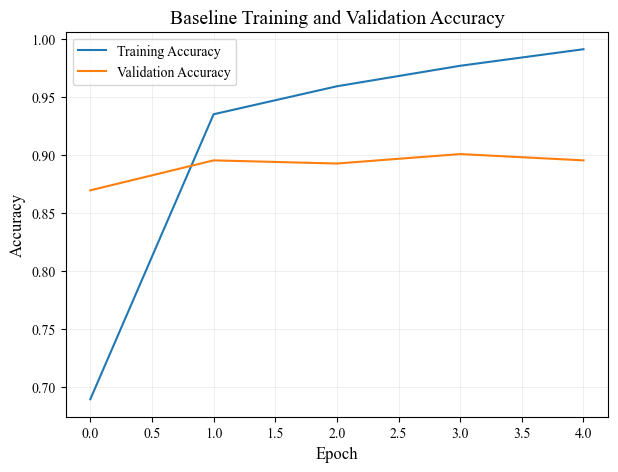

In [ ]:
# ============================================================
# CELL 13 — BASELINE ACCURACY
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.2)

save_figure("baseline_accuracy")

plt.show()

Saved: outputs/baseline_loss.eps
Saved: outputs/baseline_loss.png


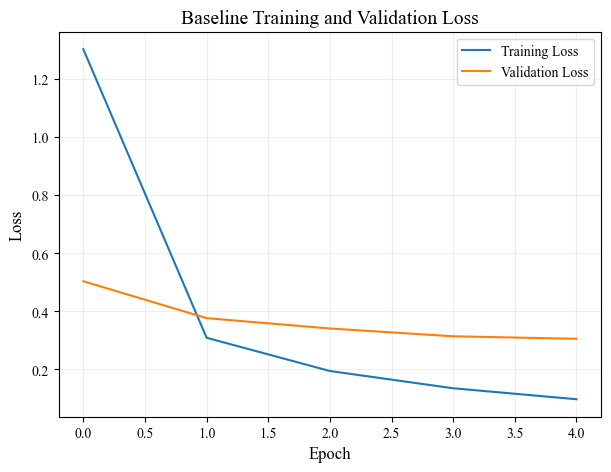

In [ ]:
# ============================================================
# CELL 14 — BASELINE LOSS
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.2)

save_figure("baseline_loss")

plt.show()

In [ ]:
# ============================================================
# CELL 15 — WEIGHT INITIALIZATION EXPERIMENT
# ============================================================

import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Initializers
# ------------------------------------------------------------

initializers = {
    "Zero": keras.initializers.Zeros(),

    "Random": keras.initializers.RandomNormal(
        mean=0.0,
        stddev=0.05,
        seed=SEED
    ),

    "Xavier": keras.initializers.GlorotUniform(
        seed=SEED
    ),

    "He": keras.initializers.HeNormal(
        seed=SEED
    )
}


# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

init_histories = {}
init_results = []


# ------------------------------------------------------------
# Train each initialization
# ------------------------------------------------------------

for name, initializer in initializers.items():

    print("\n" + "=" * 60)
    print("Initialization:", name)
    print("=" * 60)

    # Create a fresh MobileNetV2
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained base
    base_model.trainable = False


    # Build model
    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=initializer
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    init_histories[name] = history

    init_results.append({
        "Initialization": name,
        "Best Validation Accuracy (%)":
            max(history.history["val_accuracy"]) * 100,
        "Final Training Loss":
            history.history["loss"][-1],
        "Final Validation Loss":
            history.history["val_loss"][-1],
        "Training Time (s)": training_time
    })


    # Clear model from memory
    del model
    del base_model

    tf.keras.backend.clear_session()
    gc.collect()


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

init_results_df = pd.DataFrame(init_results)

display(init_results_df)


Initialization: Zero
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 158ms/step - accuracy: 0.7714 - loss: 1.1425 - val_accuracy: 0.9022 - val_loss: 0.4328
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.9426 - loss: 0.2850 - val_accuracy: 0.9117 - val_loss: 0.3539
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.9660 - loss: 0.1807 - val_accuracy: 0.9130 - val_loss: 0.3076
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.9813 - loss: 0.1258 - val_accuracy: 0.9130 - val_loss: 0.2876
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9925 - loss: 0.0905 - val_accuracy: 0.9130 - val_loss: 0.2770

Initialization: Random
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 145ms/step - accuracy: 0.6359 - loss: 1.4218 - val_accuracy: 0.8505 - val_loss: 0.5530
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.9181 - loss: 0.3369 - val_accuracy: 0.8899 - val_loss: 0.3779
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 124ms/step - accuracy

,Initialization,Best Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,Zero,91.304350,0.090472,0.277001,75.646038
1,Random,90.625000,0.105421,0.305678,73.693082
2,Xavier,90.489131,0.099241,0.296205,70.824949
3,He,90.896738,0.098784,0.306444,71.244086


In [ ]:
# index,Initialization,Best Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
# 0,Zero,91.30434989929199,0.09047173708677292,0.27700144052505493,75.64603757858276
# 1,Random,90.625,0.10542064160108566,0.30567818880081177,73.69308161735535
# 2,Xavier,90.4891312122345,0.09924113005399704,0.29620450735092163,70.82494902610779
# 3,He,90.896737575531,0.09878434240818024,0.30644431710243225,71.24408626556396

Saved: outputs/plot_1_initialization_training_loss.eps
Saved: outputs/plot_1_initialization_training_loss.png


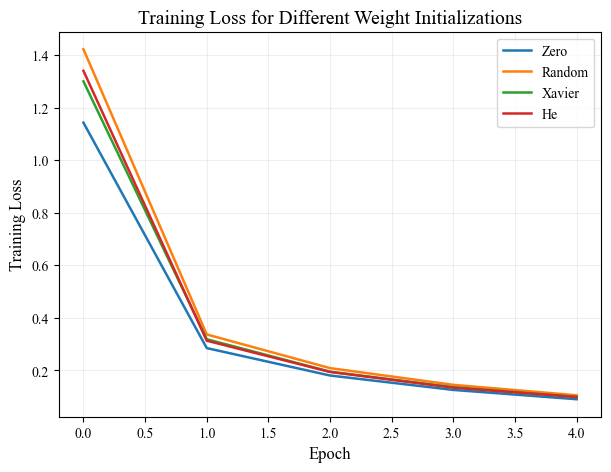

In [ ]:
# ============================================================
# CELL 16 — PLOT 1
# TRAINING LOSS vs EPOCH
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))

for name, history in init_histories.items():

    plt.plot(
        history.history["loss"],
        linewidth=1.8,
        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Weight Initializations")

plt.legend()
plt.grid(alpha=0.2)

save_figure(
    "plot_1_initialization_training_loss"
)

plt.show()
plt.close()

Saved: outputs/plot_2_initialization_validation_accuracy.eps
Saved: outputs/plot_2_initialization_validation_accuracy.png


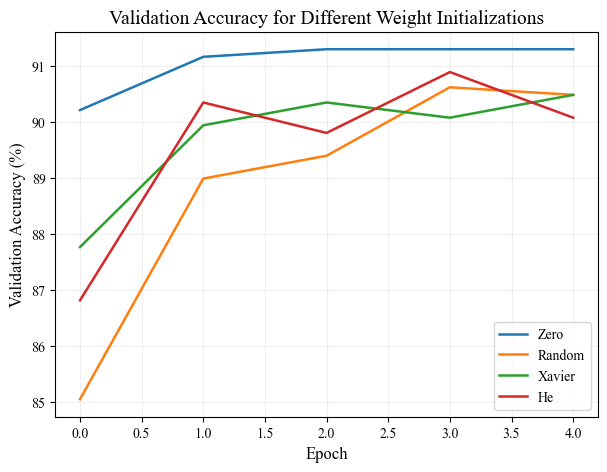

In [ ]:
# ============================================================
# CELL 17 — PLOT 2
# VALIDATION ACCURACY vs EPOCH
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))

for name, history in init_histories.items():

    plt.plot(
        np.array(history.history["val_accuracy"]) * 100,
        linewidth=1.8,
        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title(
    "Validation Accuracy for Different Weight Initializations"
)

plt.legend()
plt.grid(alpha=0.2)

save_figure(
    "plot_2_initialization_validation_accuracy"
)

plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 18 — BEST INITIALIZATION
# ============================================================

best_initialization_row = init_results_df.loc[
    init_results_df["Best Validation Accuracy (%)"].idxmax()
]

print("Best initialization:")
print(
    best_initialization_row["Initialization"]
)

print(
    f"Best validation accuracy: "
    f"{best_initialization_row['Best Validation Accuracy (%)']:.2f}%"
)

Best initialization:
Zero
Best validation accuracy: 91.30%


Best initialization:
Zero
Best validation accuracy: 91.30%

In [ ]:
# ============================================================
# CELL 19 — REGULARIZATION EXPERIMENT
# ============================================================

import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Store histories and results
# ------------------------------------------------------------

regularization_histories = {}
regularization_results = []


# ------------------------------------------------------------
# Four configurations
# ------------------------------------------------------------

regularization_configs = {

    "No Regularization": {
        "dropout": 0.0,
        "l2": 0.0,
        "batch_norm": False
    },

    "L2": {
        "dropout": 0.0,
        "l2": 0.0001,
        "batch_norm": False
    },

    "Dropout": {
        "dropout": 0.5,
        "l2": 0.0,
        "batch_norm": False
    },

    "Batch Normalization": {
        "dropout": 0.0,
        "l2": 0.0,
        "batch_norm": True
    }
}


# ------------------------------------------------------------
# Train each configuration
# ------------------------------------------------------------

for name, config in regularization_configs.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    # Fresh pretrained MobileNetV2
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze base
    base_model.trainable = False


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)


    # Batch Normalization
    if config["batch_norm"]:
        x = layers.BatchNormalization()(x)


    # Dropout
    if config["dropout"] > 0:
        x = layers.Dropout(
            config["dropout"]
        )(x)


    # L2 regularization
    if config["l2"] > 0:

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            kernel_regularizer=regularizers.l2(
                config["l2"]
            )
        )(x)

    else:

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )(x)


    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    regularization_histories[name] = history

    regularization_results.append({
        "Regularization": name,
        "Best Validation Accuracy (%)":
            max(history.history["val_accuracy"]) * 100,
        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,
        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,
        "Final Training Loss":
            history.history["loss"][-1],
        "Final Validation Loss":
            history.history["val_loss"][-1],
        "Training Time (s)": training_time
    })


    # Free memory
    del model
    del base_model

    tf.keras.backend.clear_session()
    gc.collect()


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

regularization_df = pd.DataFrame(
    regularization_results
)

display(regularization_df)


No Regularization
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 194ms/step - accuracy: 0.6960 - loss: 1.2504 - val_accuracy: 0.8750 - val_loss: 0.4956
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 99ms/step - accuracy: 0.9260 - loss: 0.3181 - val_accuracy: 0.8940 - val_loss: 0.3750
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.9589 - loss: 0.1958 - val_accuracy: 0.9008 - val_loss: 0.3289
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.9786 - loss: 0.1369 - val_accuracy: 0.9062 - val_loss: 0.3107
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.9871 - loss: 0.0994 - val_accuracy: 0.9103 - val_loss: 0.3116

L2
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 148ms/step - accuracy: 0.6834 - loss: 1.3532 - val_accuracy: 0.8832 - val_loss: 0.5081
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 103ms/step - accuracy: 0.9290 - loss: 0.3320 - val_accuracy: 0.9035 - val_loss: 0.3706
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.9599 - loss: 0.2095 

,Regularization,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,No Regularization,91.032606,98.709238,91.032606,0.099412,0.311595,99.294684
1,L2,90.760869,98.879075,90.760869,0.115803,0.299310,109.745646
2,Dropout,90.625000,93.546194,90.081519,0.220296,0.296701,107.400262
3,Batch Normalization,90.625000,99.524456,90.489131,0.049687,0.295507,88.907279


In [ ]:
# index,Regularization,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
# 0,No Regularization,91.03260636329651,98.709237575531,91.03260636329651,0.09941212832927704,0.31159457564353943,99.29468441009521
# 1,L2,90.7608687877655,98.879075050354,90.7608687877655,0.11580255627632141,0.29931047558784485,109.74564576148987
# 2,Dropout,90.625,93.5461938381195,90.08151888847351,0.22029568254947662,0.296701043844223,107.40026211738586
# 3,Batch Normalization,90.625,99.5244562625885,90.4891312122345,0.04968709498643875,0.2955073416233063,88.90727853775024

Saved: outputs/plot_3_regularization_accuracy.eps
Saved: outputs/plot_3_regularization_accuracy.png


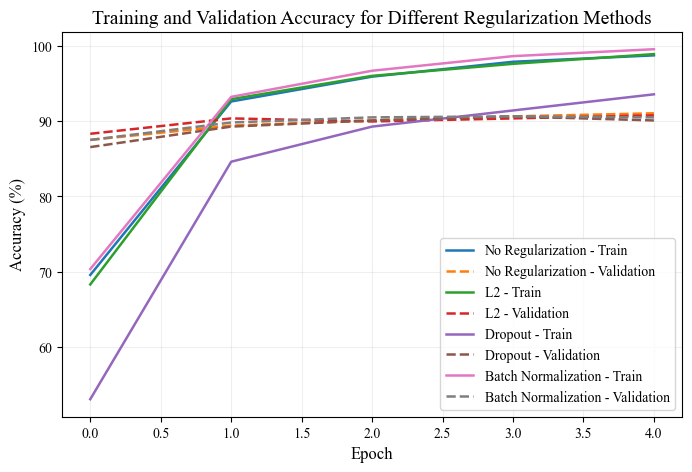

In [ ]:
# ============================================================
# CELL 20 — PLOT 3
# TRAINING AND VALIDATION ACCURACY
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))


for name, history in regularization_histories.items():

    plt.plot(
        np.array(history.history["accuracy"]) * 100,
        label=name + " - Train",
        linewidth=1.8
    )

    plt.plot(
        np.array(history.history["val_accuracy"]) * 100,
        linestyle="--",
        label=name + " - Validation",
        linewidth=1.8
    )


plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Training and Validation Accuracy for Different Regularization Methods"
)

plt.legend()
plt.grid(alpha=0.2)

save_figure(
    "plot_3_regularization_accuracy"
)

plt.show()
plt.close()

Saved: outputs/plot_4_regularization_loss.eps
Saved: outputs/plot_4_regularization_loss.png


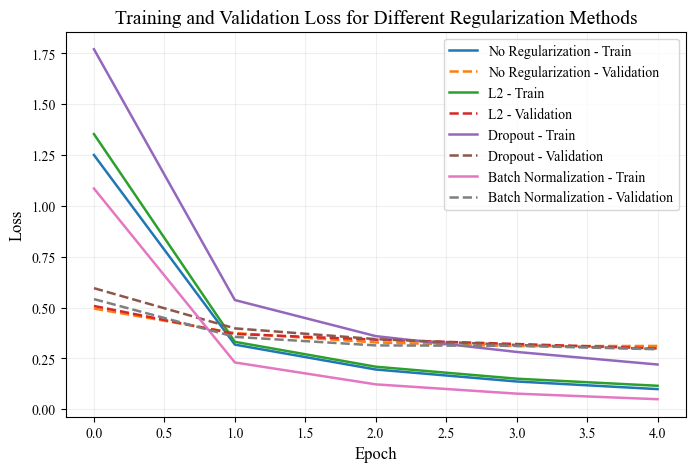

In [ ]:
# ============================================================
# CELL 21 — PLOT 4
# TRAINING AND VALIDATION LOSS
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))


for name, history in regularization_histories.items():

    plt.plot(
        history.history["loss"],
        label=name + " - Train",
        linewidth=1.8
    )

    plt.plot(
        history.history["val_loss"],
        linestyle="--",
        label=name + " - Validation",
        linewidth=1.8
    )


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss for Different Regularization Methods"
)

plt.legend()
plt.grid(alpha=0.2)

save_figure(
    "plot_4_regularization_loss"
)

plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 22 — BEST REGULARIZATION
# ============================================================

best_regularization = regularization_df.loc[
    regularization_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]

print("Best regularization method:")
print(
    best_regularization["Regularization"]
)

print(
    f"Best validation accuracy: "
    f"{best_regularization['Best Validation Accuracy (%)']:.2f}%"
)

Best regularization method:
No Regularization
Best validation accuracy: 91.03%


Best regularization method:
No Regularization
Best validation accuracy: 91.03%

In [ ]:
# ============================================================
# CELL 23 — BATCH NORMALIZATION NUMERICAL EXAMPLE
# ============================================================

import os
import numpy as np


# ------------------------------------------------------------
# Example activations
# ------------------------------------------------------------

x = np.array([
    2.0,
    4.0,
    6.0,
    8.0
])


# ------------------------------------------------------------
# Batch Normalization calculations
# ------------------------------------------------------------

# Mean
mean = np.mean(x)

# Variance
variance = np.var(x)

# Numerical stability
epsilon = 1e-5

# Normalization
x_normalized = (
    x - mean
) / np.sqrt(
    variance + epsilon
)

# Learnable scale and shift
gamma = 1.0
beta = 0.0

# Final BatchNorm output
y = gamma * x_normalized + beta


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Input:", x)
print("Mean:", mean)
print("Variance:", variance)
print("Normalized:", x_normalized)
print("Output:", y)


# ------------------------------------------------------------
# Save numerical results
# ------------------------------------------------------------

bn_results = {
    "Input": x.tolist(),
    "Mean": float(mean),
    "Variance": float(variance),
    "Epsilon": float(epsilon),
    "Gamma": float(gamma),
    "Beta": float(beta),
    "Normalized": x_normalized.tolist(),
    "Output": y.tolist()
}


# Save as NumPy file
np.save(
    os.path.join(
        OUTPUT_DIR,
        "batch_normalization_example.npy"
    ),
    bn_results,
    allow_pickle=True
)


# Save as readable text file
with open(
    os.path.join(
        OUTPUT_DIR,
        "batch_normalization_example.txt"
    ),
    "w"
) as f:

    f.write("BATCH NORMALIZATION NUMERICAL EXAMPLE\n")
    f.write("=" * 50 + "\n\n")

    f.write(f"Input: {x}\n")
    f.write(f"Mean: {mean}\n")
    f.write(f"Variance: {variance}\n")
    f.write(f"Epsilon: {epsilon}\n")
    f.write(f"Gamma: {gamma}\n")
    f.write(f"Beta: {beta}\n")
    f.write(f"Normalized: {x_normalized}\n")
    f.write(f"Output: {y}\n")


print("\nResults saved to:")
print(
    os.path.join(
        OUTPUT_DIR,
        "batch_normalization_example.npy"
    )
)

print(
    os.path.join(
        OUTPUT_DIR,
        "batch_normalization_example.txt"
    )
)

Input: [2. 4. 6. 8.]
Mean: 5.0
Variance: 5.0
Normalized: [-1.34163944 -0.44721315  0.44721315  1.34163944]
Output: [-1.34163944 -0.44721315  0.44721315  1.34163944]

Results saved to:
outputs/batch_normalization_example.npy
outputs/batch_normalization_example.txt


In [ ]:
# ============================================================
# CELL 24 — BATCH NORMALIZATION vs NO BATCH NORMALIZATION
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Configurations
# ------------------------------------------------------------

bn_configs = {
    "Without BN": False,
    "With BN": True
}


bn_histories = {}
bn_results = []


# ------------------------------------------------------------
# Train both configurations
# ------------------------------------------------------------

for name, use_bn in bn_configs.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)


    # Fresh MobileNetV2
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained layers
    base_model.trainable = False


    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)


    # Add Batch Normalization only when required
    if use_bn:

        x = layers.BatchNormalization()(x)


    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time


    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    bn_histories[name] = history


    # --------------------------------------------------------
    # Save numerical results
    # --------------------------------------------------------

    bn_results.append({

        "Configuration": name,

        "Best Validation Accuracy (%)":
            max(
                history.history["val_accuracy"]
            ) * 100,

        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,

        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    tf.keras.backend.clear_session()
    gc.collect()


# ------------------------------------------------------------
# Results DataFrame
# ------------------------------------------------------------

bn_results_df = pd.DataFrame(
    bn_results
)


display(bn_results_df)


Without BN
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.6848 - loss: 1.3164 - val_accuracy: 0.8804 - val_loss: 0.4934
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9276 - loss: 0.3095 - val_accuracy: 0.8927 - val_loss: 0.3763
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.9579 - loss: 0.1956 - val_accuracy: 0.9049 - val_loss: 0.3290
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.9789 - loss: 0.1338 - val_accuracy: 0.9076 - val_loss: 0.3134
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.9895 - loss: 0.0982 - val_accuracy: 0.9049 - val_loss: 0.2975

With BN
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.7038 - loss: 1.0485 - val_accuracy: 0.8492 - val_loss: 0.5724
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.9368 - loss: 0.2210 - val_accuracy: 0.8899 - val_loss: 0.3862
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.9735 - loss: 0.1177 -

,Configuration,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,Without BN,90.760869,98.947012,90.489131,0.098165,0.297545,94.243244
1,With BN,90.217394,99.456519,90.217394,0.052028,0.322534,80.679727


In [ ]:
# ============================================================
# CELL 25 — SAVE BN RESULTS
# ============================================================

import os


bn_csv_path = os.path.join(
    OUTPUT_DIR,
    "batch_normalization_results.csv"
)

bn_results_df.to_csv(
    bn_csv_path,
    index=False
)


print("Results saved to:")
print(bn_csv_path)

Results saved to:
outputs/batch_normalization_results.csv


Saved: outputs/plot_5_batch_normalization_validation_accuracy.eps
Saved: outputs/plot_5_batch_normalization_validation_accuracy.png


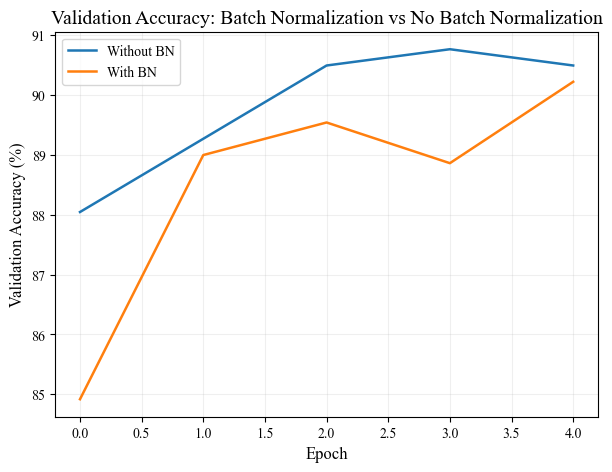

In [ ]:
# ============================================================
# CELL 26 — PLOT 5
# VALIDATION ACCURACY: BN vs NO BN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


for name, history in bn_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,

        linewidth=1.8,

        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy: Batch Normalization vs No Batch Normalization"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "plot_5_batch_normalization_validation_accuracy"
)


plt.show()
plt.close()

Saved: outputs/batch_normalization_training_loss.eps
Saved: outputs/batch_normalization_training_loss.png


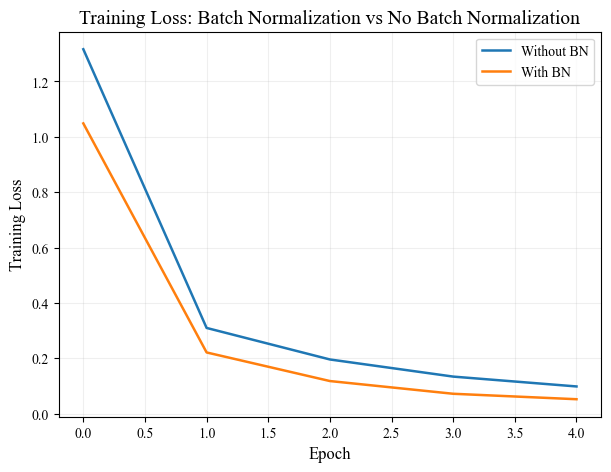

In [ ]:
# ============================================================
# CELL 27 — BN vs NO BN TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


for name, history in bn_histories.items():

    plt.plot(
        history.history["loss"],
        linewidth=1.8,
        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss: Batch Normalization vs No Batch Normalization"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "batch_normalization_training_loss"
)


plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 28 — BEST BN CONFIGURATION
# ============================================================

best_bn = bn_results_df.loc[
    bn_results_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]


print("Best configuration:")
print(
    best_bn["Configuration"]
)

print(
    f"Best validation accuracy: "
    f"{best_bn['Best Validation Accuracy (%)']:.2f}%"
)

print(
    f"Final validation accuracy: "
    f"{best_bn['Final Validation Accuracy (%)']:.2f}%"
)

Best configuration:
Without BN
Best validation accuracy: 90.76%
Final validation accuracy: 90.49%


In [ ]:
# Best configuration:
# Without BN
# Best validation accuracy: 90.76%
# Final validation accuracy: 90.49%

In [ ]:
# ============================================================
# CELL 29 — OPTIMIZER COMPARISON
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Optimizer configurations
# ------------------------------------------------------------

optimizers = {

    "SGD": keras.optimizers.SGD(
        learning_rate=0.001
    ),

    "Momentum": keras.optimizers.SGD(
        learning_rate=0.001,
        momentum=0.9
    ),

    "RMSProp": keras.optimizers.RMSprop(
        learning_rate=0.001
    ),

    "Adam": keras.optimizers.Adam(
        learning_rate=0.001
    )
}


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

optimizer_histories = {}
optimizer_results = []


# ------------------------------------------------------------
# Train each optimizer
# ------------------------------------------------------------

for name, optimizer in optimizers.items():

    print("\n" + "=" * 60)
    print("Optimizer:", name)
    print("=" * 60)


    # --------------------------------------------------------
    # Fresh MobileNetV2
    # --------------------------------------------------------

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained layers
    base_model.trainable = False


    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    optimizer_histories[name] = history


    # --------------------------------------------------------
    # Store numerical results
    # --------------------------------------------------------

    optimizer_results.append({

        "Optimizer": name,

        "Best Validation Accuracy (%)":
            max(
                history.history["val_accuracy"]
            ) * 100,

        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,

        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    tf.keras.backend.clear_session()
    gc.collect()


# ------------------------------------------------------------
# Create results table
# ------------------------------------------------------------

optimizer_results_df = pd.DataFrame(
    optimizer_results
)


display(optimizer_results_df)


Optimizer: SGD
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 147ms/step - accuracy: 0.0421 - loss: 3.7634 - val_accuracy: 0.0652 - val_loss: 3.6581
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.0768 - loss: 3.4683 - val_accuracy: 0.0910 - val_loss: 3.3869
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.1335 - loss: 3.2003 - val_accuracy: 0.1427 - val_loss: 3.1391
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.2198 - loss: 2.9544 - val_accuracy: 0.2283 - val_loss: 2.9103
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.3210 - loss: 2.7282 - val_accuracy: 0.3356 - val_loss: 2.6986

Optimizer: Momentum
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.2918 - loss: 2.8866 - val_accuracy: 0.6535 - val_loss: 1.8723
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.7734 - loss: 1.3662 - val_accuracy: 0.8084 - val_loss: 1.0442
Epoch 3/5
92/92 ━━━━━

,Optimizer,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,SGD,33.559781,32.099184,33.559781,2.728203,2.698593,97.970404
1,Momentum,89.673913,91.100544,89.673913,0.507377,0.541487,71.219938
2,RMSProp,91.168481,97.961956,91.168481,0.083705,0.281718,78.197360
3,Adam,91.168481,98.811144,91.168481,0.098706,0.288279,93.826018


In [ ]:
# ============================================================
# CELL 30 — SAVE OPTIMIZER RESULTS
# ============================================================

import os


optimizer_csv_path = os.path.join(
    OUTPUT_DIR,
    "optimizer_results.csv"
)

optimizer_results_df.to_csv(
    optimizer_csv_path,
    index=False
)


print("Optimizer results saved to:")
print(optimizer_csv_path)

Optimizer results saved to:
outputs/optimizer_results.csv


In [ ]:
# ============================================================
# CELL 31 — SAVE OPTIMIZER HISTORIES
# ============================================================

import os
import json


optimizer_history_path = os.path.join(
    OUTPUT_DIR,
    "optimizer_histories.json"
)


optimizer_history_data = {}

for name, history in optimizer_histories.items():

    optimizer_history_data[name] = {
        key: [float(value) for value in values]
        for key, values in history.history.items()
    }


with open(
    optimizer_history_path,
    "w"
) as f:

    json.dump(
        optimizer_history_data,
        f,
        indent=4
    )


print("Histories saved to:")
print(optimizer_history_path)

Histories saved to:
outputs/optimizer_histories.json


In [ ]:
# ============================================================
# CELL 32 — PLOT 6
# TRAINING LOSS vs EPOCH
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


for name, history in optimizer_histories.items():

    plt.plot(
        history.history["loss"],
        linewidth=1.8,
        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss for Different Optimizers"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "plot_6_optimizer_training_loss"
)


plt.show()
plt.close()

Saved: outputs/plot_7_optimizer_validation_accuracy.eps
Saved: outputs/plot_7_optimizer_validation_accuracy.png


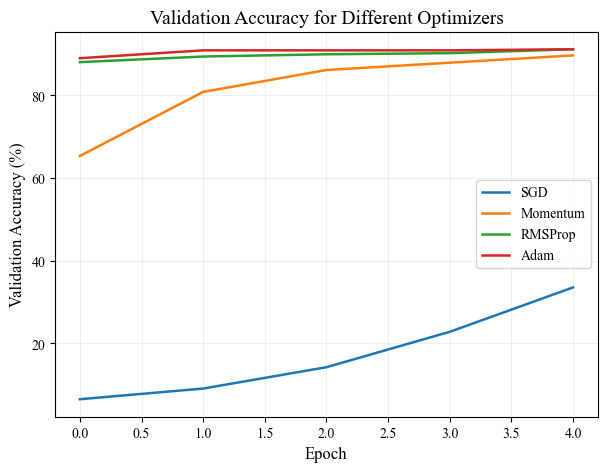

In [ ]:
# ============================================================
# CELL 33 — PLOT 7
# VALIDATION ACCURACY vs EPOCH
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(7, 5))


for name, history in optimizer_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,

        linewidth=1.8,

        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy for Different Optimizers"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "plot_7_optimizer_validation_accuracy"
)


plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 34 — BEST OPTIMIZER
# ============================================================

best_optimizer = optimizer_results_df.loc[
    optimizer_results_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]


print("Best optimizer:")
print(
    best_optimizer["Optimizer"]
)

print(
    f"Best validation accuracy: "
    f"{best_optimizer['Best Validation Accuracy (%)']:.2f}%"
)

print(
    f"Final validation accuracy: "
    f"{best_optimizer['Final Validation Accuracy (%)']:.2f}%"
)

print(
    f"Final training loss: "
    f"{best_optimizer['Final Training Loss']:.4f}"
)

Best optimizer:
RMSProp
Best validation accuracy: 91.17%
Final validation accuracy: 91.17%
Final training loss: 0.0837


In [ ]:
# ============================================================
# CELL 35 — HYPERPARAMETER TUNING
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Hyperparameter values
# ------------------------------------------------------------

learning_rates = [
    0.001,
    0.0001
]

batch_sizes = [
    16,
    32,
    64
]

dropout_rates = [
    0.0,
    0.25,
    0.5
]


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

hyperparameter_histories = {}

hyperparameter_results = []


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def build_hyperparameter_model(dropout_rate):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False


    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)


    if dropout_rate > 0:

        x = layers.Dropout(
            dropout_rate
        )(x)


    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = keras.Model(
        inputs,
        outputs
    )

    return model


# ============================================================
# 1. LEARNING RATE EXPERIMENT
# ============================================================

for lr in learning_rates:

    print("\n" + "=" * 60)
    print("Learning Rate:", lr)
    print("=" * 60)


    model = build_hyperparameter_model(
        dropout_rate=0.0
    )


    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=lr
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    start_time = time.time()


    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )


    training_time = time.time() - start_time


    key = f"Learning Rate = {lr}"

    hyperparameter_histories[key] = history


    hyperparameter_results.append({

        "Hyperparameter": "Learning Rate",

        "Value": lr,

        "Best Validation Accuracy (%)":
            max(history.history["val_accuracy"]) * 100,

        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,

        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


    del model

    tf.keras.backend.clear_session()
    gc.collect()


# ============================================================
# 2. BATCH SIZE EXPERIMENT
# ============================================================

for batch_size in batch_sizes:

    print("\n" + "=" * 60)
    print("Batch Size:", batch_size)
    print("=" * 60)


    # Create datasets with this batch size
    train_batch_ds = make_dataset(
        train_raw,
        batch_size=batch_size,
        shuffle=True
    )

    val_batch_ds = make_dataset(
        val_raw,
        batch_size=batch_size,
        shuffle=False
    )


    model = build_hyperparameter_model(
        dropout_rate=0.0
    )


    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    start_time = time.time()


    history = model.fit(
        train_batch_ds,
        validation_data=val_batch_ds,
        epochs=EPOCHS,
        verbose=1
    )


    training_time = time.time() - start_time


    key = f"Batch Size = {batch_size}"

    hyperparameter_histories[key] = history


    hyperparameter_results.append({

        "Hyperparameter": "Batch Size",

        "Value": batch_size,

        "Best Validation Accuracy (%)":
            max(history.history["val_accuracy"]) * 100,

        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,

        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


    del model

    tf.keras.backend.clear_session()
    gc.collect()


# ============================================================
# 3. DROPOUT EXPERIMENT
# ============================================================

for dropout_rate in dropout_rates:

    print("\n" + "=" * 60)
    print("Dropout:", dropout_rate)
    print("=" * 60)


    model = build_hyperparameter_model(
        dropout_rate=dropout_rate
    )


    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    start_time = time.time()


    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )


    training_time = time.time() - start_time


    key = f"Dropout = {dropout_rate}"

    hyperparameter_histories[key] = history


    hyperparameter_results.append({

        "Hyperparameter": "Dropout",

        "Value": dropout_rate,

        "Best Validation Accuracy (%)":
            max(history.history["val_accuracy"]) * 100,

        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,

        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


    del model

    tf.keras.backend.clear_session()
    gc.collect()


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

hyperparameter_df = pd.DataFrame(
    hyperparameter_results
)

display(hyperparameter_df)


Learning Rate: 0.001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 143ms/step - accuracy: 0.7310 - loss: 1.1472 - val_accuracy: 0.8818 - val_loss: 0.4506
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.9226 - loss: 0.2853 - val_accuracy: 0.9035 - val_loss: 0.3297
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.9572 - loss: 0.1673 - val_accuracy: 0.9144 - val_loss: 0.2936
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.9725 - loss: 0.1158 - val_accuracy: 0.9144 - val_loss: 0.2674
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.9823 - loss: 0.0803 - val_accuracy: 0.9035 - val_loss: 0.2885

Learning Rate: 0.0001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - accuracy: 0.1478 - loss: 3.2722 - val_accuracy: 0.3329 - val_loss: 2.7147
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.5000 - loss: 2.2403 - val_accuracy: 0.6264 - val_loss: 1.8877
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 

,Hyperparameter,Value,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,Learning Rate,0.0010,91.440219,98.233694,90.353262,0.080289,0.288501,81.536150
1,Learning Rate,0.0001,83.695650,86.447012,83.695650,0.794774,0.782480,87.057510
2,Batch Size,16.0000,90.081519,98.199731,89.945650,0.071474,0.296993,99.940292
3,Batch Size,32.0000,90.760869,98.369563,90.625000,0.082152,0.299600,70.461892
4,Batch Size,64.0000,90.760869,97.588313,90.217394,0.118086,0.300382,89.714669
5,Dropout,0.0000,91.983694,98.199731,91.983694,0.078998,0.272916,87.516919
6,Dropout,0.2500,90.896738,96.297556,90.896738,0.127690,0.287774,78.170941
7,Dropout,0.5000,90.760869,92.459238,90.760869,0.217774,0.300840,87.131225


In [ ]:
# ============================================================
# CELL 36 — SAVE HYPERPARAMETER RESULTS
# ============================================================

import os
import pandas as pd


hyperparameter_csv_path = os.path.join(
    OUTPUT_DIR,
    "hyperparameter_results.csv"
)

hyperparameter_df.to_csv(
    hyperparameter_csv_path,
    index=False
)

print("Results saved to:")
print(hyperparameter_csv_path)


Results saved to:
outputs/hyperparameter_results.csv


Saved: outputs/plot_8_learning_rate.eps
Saved: outputs/plot_8_learning_rate.png


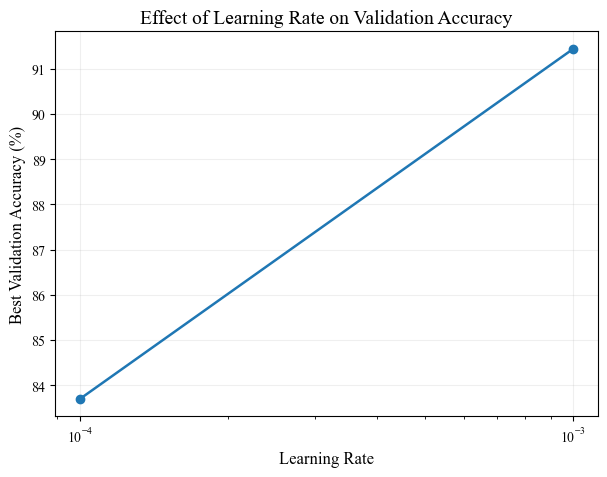

In [ ]:
# ============================================================
# CELL 37 — PLOT 8
# LEARNING RATE COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


lr_df = hyperparameter_df[
    hyperparameter_df["Hyperparameter"] == "Learning Rate"
]


plt.figure(figsize=(7, 5))

plt.plot(
    lr_df["Value"].astype(float),
    lr_df["Best Validation Accuracy (%)"],
    marker="o",
    linewidth=1.8
)

plt.xlabel("Learning Rate")
plt.ylabel("Best Validation Accuracy (%)")

plt.title(
    "Effect of Learning Rate on Validation Accuracy"
)

plt.xscale("log")

plt.grid(alpha=0.2)

save_figure(
    "plot_8_learning_rate"
)

plt.show()
plt.close()

Saved: outputs/plot_9_batch_size.eps
Saved: outputs/plot_9_batch_size.png


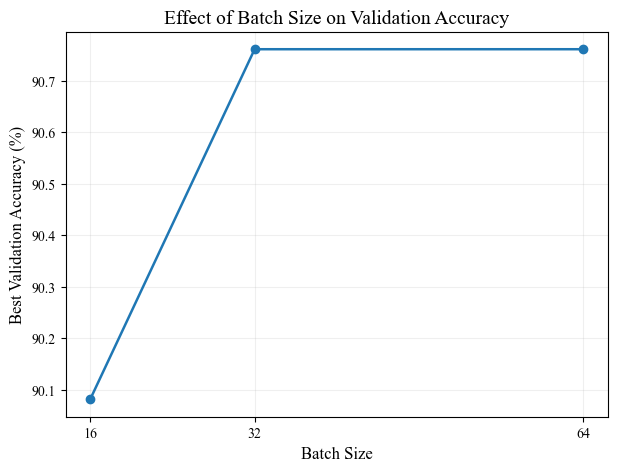

In [ ]:
# ============================================================
# CELL 38 — PLOT 9
# BATCH SIZE COMPARISON
# ============================================================

import matplotlib.pyplot as plt


batch_df = hyperparameter_df[
    hyperparameter_df["Hyperparameter"] == "Batch Size"
]


plt.figure(figsize=(7, 5))

plt.plot(
    batch_df["Value"].astype(float),
    batch_df["Best Validation Accuracy (%)"],
    marker="o",
    linewidth=1.8
)

plt.xlabel("Batch Size")
plt.ylabel("Best Validation Accuracy (%)")

plt.title(
    "Effect of Batch Size on Validation Accuracy"
)

plt.xticks([16, 32, 64])

plt.grid(alpha=0.2)

save_figure(
    "plot_9_batch_size"
)

plt.show()
plt.close()

Saved: outputs/plot_10_dropout.eps
Saved: outputs/plot_10_dropout.png


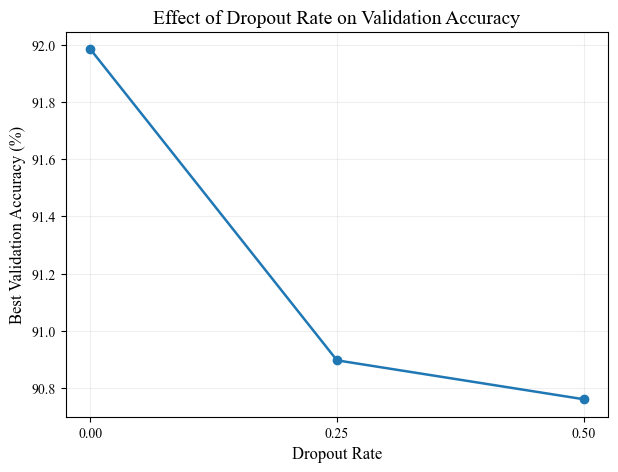

In [ ]:
# ============================================================
# CELL 39 — PLOT 10
# DROPOUT COMPARISON
# ============================================================

import matplotlib.pyplot as plt


dropout_df = hyperparameter_df[
    hyperparameter_df["Hyperparameter"] == "Dropout"
]


plt.figure(figsize=(7, 5))

plt.plot(
    dropout_df["Value"].astype(float),
    dropout_df["Best Validation Accuracy (%)"],
    marker="o",
    linewidth=1.8
)

plt.xlabel("Dropout Rate")
plt.ylabel("Best Validation Accuracy (%)")

plt.title(
    "Effect of Dropout Rate on Validation Accuracy"
)

plt.xticks([0, 0.25, 0.5])

plt.grid(alpha=0.2)

save_figure(
    "plot_10_dropout"
)

plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 40 — SELECTED HYPERPARAMETERS
# ============================================================

import pandas as pd


selected_configuration = {
    "Optimizer": "RMSProp",
    "Learning Rate": 0.001,
    "Batch Size": 32,
    "Dropout": 0.0
}


selected_df = pd.DataFrame(
    [selected_configuration]
)


display(selected_df)

,Optimizer,Learning Rate,Batch Size,Dropout
0,RMSProp,0.001,32,0.0


In [ ]:
# ============================================================
# SAVE SELECTED CONFIGURATION
# ============================================================

import os


selected_config_path = os.path.join(
    OUTPUT_DIR,
    "selected_hyperparameters.csv"
)

selected_df.to_csv(
    selected_config_path,
    index=False
)

print("Selected configuration saved to:")
print(selected_config_path)

Selected configuration saved to:
outputs/selected_hyperparameters.csv


In [ ]:
# ============================================================
# CELL 41 — TRANSFER LEARNING COMPARISON
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Configuration selected from previous experiments
# ------------------------------------------------------------

FINAL_LR = 0.001
FINAL_BATCH_SIZE = 32
FINAL_DROPOUT = 0.0


transfer_histories = {}
transfer_results = []


# ------------------------------------------------------------
# Two transfer-learning strategies
# ------------------------------------------------------------

transfer_configs = {

    "Feature Extraction": {
        "fine_tune": False
    },

    "Fine-Tuning": {
        "fine_tune": True
    }
}


# ------------------------------------------------------------
# Train both approaches
# ------------------------------------------------------------

for name, config in transfer_configs.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)


    # --------------------------------------------------------
    # Fresh pretrained MobileNetV2
    # --------------------------------------------------------

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )


    # --------------------------------------------------------
    # Feature Extraction
    # --------------------------------------------------------

    if not config["fine_tune"]:

        base_model.trainable = False


    # --------------------------------------------------------
    # Fine-Tuning
    # --------------------------------------------------------

    else:

        base_model.trainable = True

        # Freeze most of the network
        # and fine-tune only the last 20 layers

        for layer in base_model.layers[:-20]:
            layer.trainable = False


    # --------------------------------------------------------
    # Build classifier
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=FINAL_LR
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # --------------------------------------------------------
    # Count trainable parameters
    # --------------------------------------------------------

    trainable_params = np.sum([
        np.prod(v.shape)
        for v in model.trainable_variables
    ])


    total_params = model.count_params()


    print(
        "Trainable parameters:",
        trainable_params
    )

    print(
        "Total parameters:",
        total_params
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    transfer_histories[name] = history


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    transfer_results.append({

        "Transfer Learning Method": name,

        "Trainable Parameters": int(
            trainable_params
        ),

        "Total Parameters": int(
            total_params
        ),

        "Best Validation Accuracy (%)":
            max(
                history.history["val_accuracy"]
            ) * 100,

        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,

        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    tf.keras.backend.clear_session()
    gc.collect()


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

transfer_results_df = pd.DataFrame(
    transfer_results
)

display(transfer_results_df)


Feature Extraction
Trainable parameters: 47397
Total parameters: 2305381
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 164ms/step - accuracy: 0.7221 - loss: 1.1726 - val_accuracy: 0.8764 - val_loss: 0.4749
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - accuracy: 0.9202 - loss: 0.2881 - val_accuracy: 0.8913 - val_loss: 0.3428
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.9575 - loss: 0.1686 - val_accuracy: 0.8913 - val_loss: 0.3274
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.9718 - loss: 0.1153 - val_accuracy: 0.9062 - val_loss: 0.2951
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.9820 - loss: 0.0804 - val_accuracy: 0.9090 - val_loss: 0.2814

Fine-Tuning
Trainable parameters: 1253477
Total parameters: 2305381
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 158ms/step - accuracy: 0.7490 - loss: 0.8467 - val_accuracy: 0.7323 - val_loss: 1.4208
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.9025 - loss: 0.2998 - val_a

,Transfer Learning Method,Trainable Parameters,Total Parameters,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,Feature Extraction,47397,2305381,90.896738,98.199731,90.896738,0.080379,0.281438,88.256069
1,Fine-Tuning,1253477,2305381,73.233694,97.010869,25.951087,0.089898,11.596931,84.059751


In [ ]:
# ============================================================
# CELL 42 — SAVE TRANSFER LEARNING RESULTS
# ============================================================

import os


transfer_csv_path = os.path.join(
    OUTPUT_DIR,
    "transfer_learning_results.csv"
)

transfer_results_df.to_csv(
    transfer_csv_path,
    index=False
)

print("Results saved to:")
print(transfer_csv_path)

Results saved to:
outputs/transfer_learning_results.csv


Saved: outputs/transfer_learning_validation_accuracy.eps
Saved: outputs/transfer_learning_validation_accuracy.png


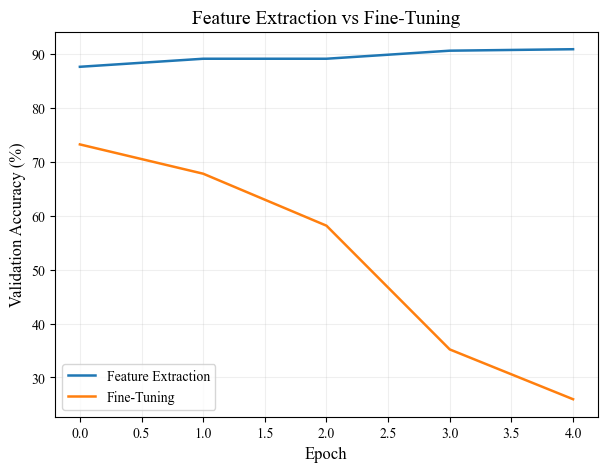

In [ ]:
# ============================================================
# CELL 43 — TRANSFER LEARNING VALIDATION ACCURACY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


for name, history in transfer_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,

        linewidth=1.8,

        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(alpha=0.2)

save_figure(
    "transfer_learning_validation_accuracy"
)

plt.show()
plt.close()

Saved: outputs/transfer_learning_training_loss.eps
Saved: outputs/transfer_learning_training_loss.png


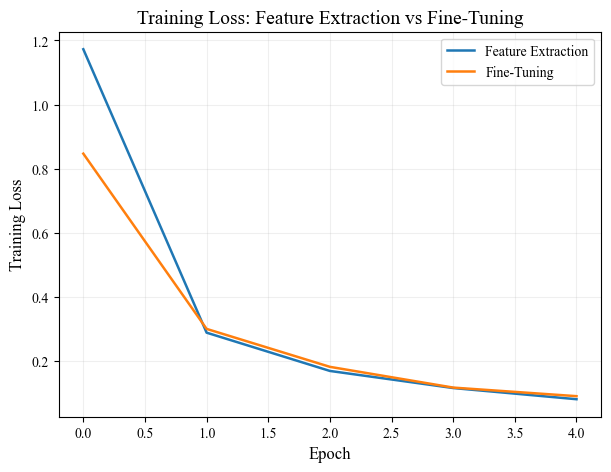

In [ ]:
# ============================================================
# CELL 44 — TRANSFER LEARNING TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


for name, history in transfer_histories.items():

    plt.plot(
        history.history["loss"],
        linewidth=1.8,
        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss: Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(alpha=0.2)

save_figure(
    "transfer_learning_training_loss"
)

plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 45 — BEST TRANSFER LEARNING METHOD
# ============================================================

best_transfer = transfer_results_df.loc[
    transfer_results_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]


print("Best transfer-learning method:")
print(
    best_transfer[
        "Transfer Learning Method"
    ]
)

print(
    f"Best validation accuracy: "
    f"{best_transfer['Best Validation Accuracy (%)']:.2f}%"
)

print(
    f"Trainable parameters: "
    f"{best_transfer['Trainable Parameters']:,}"
)

print(
    f"Training time: "
    f"{best_transfer['Training Time (s)']:.2f} seconds"
)

Best transfer-learning method:
Feature Extraction
Best validation accuracy: 90.90%
Trainable parameters: 47,397
Training time: 88.26 seconds


In [ ]:
# ============================================================
# CELL 46 — CORRECT FINE-TUNING EXPERIMENT
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Fine-tuning learning rate from the manual
# ------------------------------------------------------------

FINE_TUNE_LR = 0.0001

FINE_TUNE_EPOCHS = EPOCHS


# ------------------------------------------------------------
# Load fresh pretrained MobileNetV2
# ------------------------------------------------------------

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)


# ------------------------------------------------------------
# Freeze most layers
# ------------------------------------------------------------

base_model.trainable = True


# Keep only the final 20 layers trainable
for layer in base_model.layers[:-20]:

    layer.trainable = False


# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

inputs = keras.Input(
    shape=(224, 224, 3)
)

x = base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


fine_tune_model = keras.Model(
    inputs,
    outputs
)


# ------------------------------------------------------------
# Compile with SMALL learning rate
# ------------------------------------------------------------

fine_tune_model.compile(
    optimizer=keras.optimizers.RMSprop(
        learning_rate=FINE_TUNE_LR
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

trainable_params = np.sum([
    np.prod(v.shape)
    for v in fine_tune_model.trainable_variables
])

total_params = fine_tune_model.count_params()


print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Fine-tuning learning rate:",
    FINE_TUNE_LR
)


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

start_time = time.time()


fine_tune_history = fine_tune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1
)


fine_tune_time = time.time() - start_time


print(
    f"\nTraining time: "
    f"{fine_tune_time:.2f} seconds"
)

Trainable parameters: 1,253,477
Total parameters: 2,305,381
Fine-tuning learning rate: 0.0001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.6933 - loss: 1.3763 - val_accuracy: 0.8438 - val_loss: 0.5683
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.9263 - loss: 0.3080 - val_accuracy: 0.8764 - val_loss: 0.4314
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - accuracy: 0.9718 - loss: 0.1407 - val_accuracy: 0.8886 - val_loss: 0.3685
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.9915 - loss: 0.0701 - val_accuracy: 0.9022 - val_loss: 0.3308
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.9976 - loss: 0.0348 - val_accuracy: 0.8954 - val_loss: 0.3275

Training time: 85.27 seconds


In [ ]:
# ============================================================
# CELL 47 — SAVE FINE-TUNING RESULTS
# ============================================================

import os
import pandas as pd


fine_tune_results = pd.DataFrame([
    {
        "Method": "Fine-Tuning",

        "Learning Rate": FINE_TUNE_LR,

        "Trainable Parameters":
            int(trainable_params),

        "Total Parameters":
            int(total_params),

        "Best Validation Accuracy (%)":
            max(
                fine_tune_history.history[
                    "val_accuracy"
                ]
            ) * 100,

        "Final Training Accuracy (%)":
            fine_tune_history.history[
                "accuracy"
            ][-1] * 100,

        "Final Validation Accuracy (%)":
            fine_tune_history.history[
                "val_accuracy"
            ][-1] * 100,

        "Final Training Loss":
            fine_tune_history.history[
                "loss"
            ][-1],

        "Final Validation Loss":
            fine_tune_history.history[
                "val_loss"
            ][-1],

        "Training Time (s)":
            fine_tune_time
    }
])


fine_tune_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "correct_fine_tuning_results.csv"
    ),
    index=False
)


display(fine_tune_results)

,Method,Learning Rate,Trainable Parameters,Total Parameters,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,Fine-Tuning,0.0001,1253477,2305381,90.217394,99.762231,89.538044,0.034841,0.327515,85.268207


Saved: outputs/plot_11_feature_extraction_vs_fine_tuning.eps
Saved: outputs/plot_11_feature_extraction_vs_fine_tuning.png


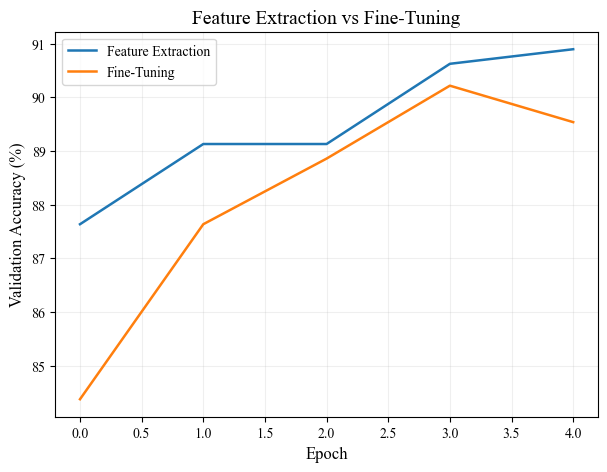

In [ ]:
# ============================================================
# CELL 48 — PLOT 11
# FEATURE EXTRACTION vs FINE-TUNING
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


# Feature Extraction
plt.plot(
    np.array(
        transfer_histories[
            "Feature Extraction"
        ].history["val_accuracy"]
    ) * 100,

    linewidth=1.8,

    label="Feature Extraction"
)


# Correct Fine-Tuning
plt.plot(
    np.array(
        fine_tune_history.history[
            "val_accuracy"
        ]
    ) * 100,

    linewidth=1.8,

    label="Fine-Tuning"
)


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "plot_11_feature_extraction_vs_fine_tuning"
)


plt.show()
plt.close()

Saved: outputs/plot_12_transfer_learning_loss.eps
Saved: outputs/plot_12_transfer_learning_loss.png


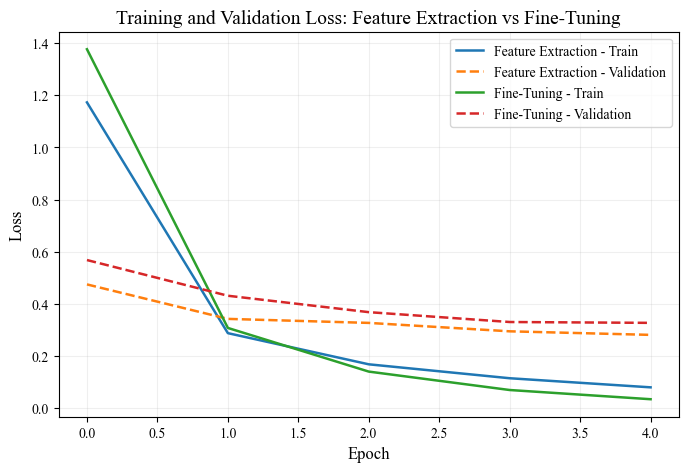

In [ ]:
# ============================================================
# CELL 49 — PLOT 12
# TRAINING AND VALIDATION LOSS
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))


# ------------------------------------------------------------
# Feature Extraction
# ------------------------------------------------------------

plt.plot(
    transfer_histories[
        "Feature Extraction"
    ].history["loss"],

    linewidth=1.8,

    label="Feature Extraction - Train"
)


plt.plot(
    transfer_histories[
        "Feature Extraction"
    ].history["val_loss"],

    linestyle="--",

    linewidth=1.8,

    label="Feature Extraction - Validation"
)


# ------------------------------------------------------------
# Fine-Tuning
# ------------------------------------------------------------

plt.plot(
    fine_tune_history.history["loss"],

    linewidth=1.8,

    label="Fine-Tuning - Train"
)


plt.plot(
    fine_tune_history.history["val_loss"],

    linestyle="--",

    linewidth=1.8,

    label="Fine-Tuning - Validation"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss: "
    "Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "plot_12_transfer_learning_loss"
)


plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 50 — PREPARE 5-FOLD CROSS-VALIDATION
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

from sklearn.model_selection import StratifiedKFold


# ------------------------------------------------------------
# Get labels ONLY
# We do NOT load the images into NumPy.
# ------------------------------------------------------------

cv_labels = np.array([
    label.numpy()
    for _, label in train_raw
])


print("Number of training samples:", len(cv_labels))
print("Number of classes:", len(np.unique(cv_labels)))


# ------------------------------------------------------------
# Create 5 folds
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


folds = list(
    skf.split(
        np.zeros(len(cv_labels)),
        cv_labels
    )
)


print("\n5 folds created.")

for fold_number, (train_indices, val_indices) in enumerate(
    folds,
    start=1
):

    print(
        f"Fold {fold_number}: "
        f"Train = {len(train_indices)}, "

        f"Validation = {len(val_indices)}"
    )

Number of training samples: 2944
Number of classes: 37

5 folds created.
Fold 1: Train = 2355, Validation = 589
Fold 2: Train = 2355, Validation = 589
Fold 3: Train = 2355, Validation = 589
Fold 4: Train = 2355, Validation = 589
Fold 5: Train = 2356, Validation = 588


In [ ]:
# ============================================================
# CELL 51 — CREATE DATASET FOR A SPECIFIC FOLD
# ============================================================

def create_fold_dataset(
    raw_dataset,
    indices,
    batch_size,
    shuffle=False
):

    # Convert selected indices into a TensorFlow tensor
    indices_tensor = tf.constant(
        indices,
        dtype=tf.int64
    )


    # Create a lookup table:
    # selected index -> 1
    keys = indices_tensor

    values = tf.ones_like(
        indices_tensor,
        dtype=tf.int64
    )


    table = tf.lookup.StaticHashTable(
        tf.lookup.KeyValueTensorInitializer(
            keys,
            values
        ),
        default_value=0
    )


    # Enumerate dataset so every image has an index
    dataset = raw_dataset.enumerate()


    # Keep only requested indices
    dataset = dataset.filter(
        lambda index, data:
        table.lookup(index) == 1
    )


    # Remove enumeration index
    dataset = dataset.map(
        lambda index, data: data,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    # Normal preprocessing
    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    if shuffle:

        dataset = dataset.shuffle(
            1000,
            seed=SEED
        )


    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )


    return dataset

In [ ]:
# ============================================================
# CELL 52 — MODEL BUILDER FOR CROSS-VALIDATION
# ============================================================

def build_cv_model(
    initialization="normal",
    fine_tune=False
):

    # --------------------------------------------------------
    # MobileNetV2
    # --------------------------------------------------------

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )


    # --------------------------------------------------------
    # Freeze / Fine-Tune
    # --------------------------------------------------------

    if fine_tune:

        base_model.trainable = True

        # Freeze all but last 20 layers
        for layer in base_model.layers[:-20]:

            layer.trainable = False

    else:

        base_model.trainable = False


    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )


    x = base_model(
        inputs,
        training=False
    )


    x = layers.GlobalAveragePooling2D()(x)


    # --------------------------------------------------------
    # Classifier initialization
    # --------------------------------------------------------

    if initialization == "zero":

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            kernel_initializer=keras.initializers.Zeros()
        )(x)

    else:

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )(x)


    model = keras.Model(
        inputs,
        outputs
    )


    return model

In [ ]:
# ============================================================
# CELL 53 — CV CONFIGURATIONS
# ============================================================

cv_configs = {

    "C1 - Baseline": {
        "initialization": "normal",
        "fine_tune": False,
        "learning_rate": 0.001
    },

    "C2 - Zero Initialization": {
        "initialization": "zero",
        "fine_tune": False,
        "learning_rate": 0.001
    },

    "C3 - Fine-Tuning": {
        "initialization": "normal",
        "fine_tune": True,
        "learning_rate": 0.0001
    }
}


display(
    pd.DataFrame(cv_configs).T
)

,initialization,fine_tune,learning_rate
C1 - Baseline,normal,False,0.001
C2 - Zero Initialization,zero,False,0.001
C3 - Fine-Tuning,normal,True,0.0001


In [ ]:
# ============================================================
# CELL 51 — FIXED FOLD DATASET
# ============================================================

def create_fold_dataset(
    raw_dataset,
    indices,
    batch_size,
    shuffle=False
):

    # --------------------------------------------------------
    # Create lookup table for selected indices
    # --------------------------------------------------------

    indices_tensor = tf.constant(
        indices,
        dtype=tf.int64
    )

    values = tf.ones_like(
        indices_tensor,
        dtype=tf.int64
    )

    table = tf.lookup.StaticHashTable(
        tf.lookup.KeyValueTensorInitializer(
            indices_tensor,
            values
        ),
        default_value=0
    )


    # --------------------------------------------------------
    # Add index to every sample
    # --------------------------------------------------------

    dataset = raw_dataset.enumerate()


    # --------------------------------------------------------
    # Keep only samples belonging to this fold
    # --------------------------------------------------------

    dataset = dataset.filter(
        lambda index, data:
        table.lookup(index) == 1
    )


    # Remove index
    dataset = dataset.map(
        lambda index, data: data,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    # --------------------------------------------------------
    # Preprocess
    # --------------------------------------------------------

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    # --------------------------------------------------------
    # Shuffle
    # --------------------------------------------------------

    if shuffle:

        dataset = dataset.shuffle(
            1000,
            seed=SEED,
            reshuffle_each_iteration=True
        )


    # --------------------------------------------------------
    # IMPORTANT:
    # Repeat forever so Keras never runs out of data
    # --------------------------------------------------------

    dataset = dataset.repeat()


    # --------------------------------------------------------
    # Batch
    # --------------------------------------------------------

    dataset = dataset.batch(
        batch_size
    )


    # --------------------------------------------------------
    # Prefetch
    # --------------------------------------------------------

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )


    return dataset

In [ ]:
# ============================================================
# CELL 54 — RUN 5-FOLD CROSS-VALIDATION
# FIXED VERSION
# ============================================================

cv_results = []


for config_name, config in cv_configs.items():

    print("\n")
    print("#" * 70)
    print(config_name)
    print("#" * 70)


    for fold_number, (train_indices, val_indices) in enumerate(
        folds,
        start=1
    ):

        print("\n" + "-" * 60)

        print(
            f"{config_name} | "
            f"Fold {fold_number}/5"
        )

        print("-" * 60)


        # ----------------------------------------------------
        # Number of samples in each fold
        # ----------------------------------------------------

        num_train_samples = len(train_indices)

        num_val_samples = len(val_indices)


        # Number of batches per epoch
        steps_per_epoch = int(
            np.ceil(
                num_train_samples / 32
            )
        )

        validation_steps = int(
            np.ceil(
                num_val_samples / 32
            )
        )


        print(
            "Training samples:",
            num_train_samples
        )

        print(
            "Validation samples:",
            num_val_samples
        )

        print(
            "Steps per epoch:",
            steps_per_epoch
        )

        print(
            "Validation steps:",
            validation_steps
        )


        # ----------------------------------------------------
        # Create fold datasets
        # ----------------------------------------------------

        fold_train_ds = create_fold_dataset(
            train_raw,
            train_indices,
            batch_size=32,
            shuffle=True
        )


        fold_val_ds = create_fold_dataset(
            train_raw,
            val_indices,
            batch_size=32,
            shuffle=False
        )


        # ----------------------------------------------------
        # Build fresh model
        # ----------------------------------------------------

        model = build_cv_model(
            initialization=config["initialization"],
            fine_tune=config["fine_tune"]
        )


        # ----------------------------------------------------
        # Compile
        # ----------------------------------------------------

        model.compile(

            optimizer=keras.optimizers.RMSprop(
                learning_rate=config["learning_rate"]
            ),

            loss="sparse_categorical_crossentropy",

            metrics=["accuracy"]
        )


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        start_time = time.time()


        history = model.fit(

            fold_train_ds,

            validation_data=fold_val_ds,

            epochs=EPOCHS,

            steps_per_epoch=steps_per_epoch,

            validation_steps=validation_steps,

            verbose=1
        )


        training_time = time.time() - start_time


        # ----------------------------------------------------
        # Best validation accuracy
        # ----------------------------------------------------

        best_val_accuracy = max(
            history.history["val_accuracy"]
        ) * 100


        # ----------------------------------------------------
        # Final validation accuracy
        # ----------------------------------------------------

        final_val_accuracy = (
            history.history["val_accuracy"][-1]
            * 100
        )


        # ----------------------------------------------------
        # Save fold result
        # ----------------------------------------------------

        cv_results.append({

            "Configuration": config_name,

            "Fold": fold_number,

            "Best Validation Accuracy (%)":
                best_val_accuracy,

            "Final Validation Accuracy (%)":
                final_val_accuracy,

            "Training Time (s)":
                training_time
        })


        print(
            f"Best validation accuracy: "
            f"{best_val_accuracy:.2f}%"
        )


        # ----------------------------------------------------
        # Clear memory
        # ----------------------------------------------------

        del model
        del fold_train_ds
        del fold_val_ds

        tf.keras.backend.clear_session()

        gc.collect()


# ------------------------------------------------------------
# Results DataFrame
# ------------------------------------------------------------

cv_results_df = pd.DataFrame(
    cv_results
)


display(cv_results_df)



######################################################################
C1 - Baseline
######################################################################

------------------------------------------------------------
C1 - Baseline | Fold 1/5
------------------------------------------------------------
Training samples: 2355
Validation samples: 589
Steps per epoch: 74
Validation steps: 19
Epoch 1/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 276ms/step - accuracy: 0.7027 - loss: 1.3064 - val_accuracy: 0.8750 - val_loss: 0.5041
Epoch 2/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 294ms/step - accuracy: 0.9189 - loss: 0.3322 - val_accuracy: 0.9128 - val_loss: 0.3252
Epoch 3/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 294ms/step - accuracy: 0.9476 - loss: 0.1934 - val_accuracy: 0.9128 - val_loss: 0.2714
Epoch 4/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 234ms/step - accuracy: 0.9734 - loss: 0.1281 - val_accuracy: 0.9095 - val_loss: 0.2430
Epoch 5/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.9823 - loss: 0.0898 - val_ac

,Configuration,Fold,Best Validation Accuracy (%),Final Validation Accuracy (%),Training Time (s)
0,C1 - Baseline,1,91.776317,91.776317,111.120483
1,C1 - Baseline,2,91.611844,90.460527,95.382056
2,C1 - Baseline,3,91.940790,91.282892,98.444164
3,C1 - Baseline,4,91.118419,91.118419,99.508641
4,C1 - Baseline,5,91.282892,91.282892,98.860876
5,C2 - Zero Initialization,1,92.763156,92.105263,93.851117
6,C2 - Zero Initialization,2,91.282892,91.118419,96.438579
7,C2 - Zero Initialization,3,91.940790,91.940790,145.597430
8,C2 - Zero Initialization,4,90.789473,90.789473,99.238364
9,C2 - Zero Initialization,5,91.776317,91.776317,96.709828


In [ ]:
# ============================================================
# CELL 55 — 5-FOLD CV SUMMARY
# ============================================================

cv_summary = (
    cv_results_df
    .groupby("Configuration")["Best Validation Accuracy (%)"]
    .agg(
        Mean="mean",
        SD="std"
    )
    .reset_index()
)

display(cv_summary)

,Configuration,Mean,SD
0,C1 - Baseline,91.546053,0.341062
1,C2 - Zero Initialization,91.710526,0.741045
2,C3 - Fine-Tuning,90.197369,0.897851


In [ ]:
# ============================================================
# CELL 56 — ADD TRAINING TIME
# ============================================================

time_summary = (
    cv_results_df
    .groupby("Configuration")["Training Time (s)"]
    .mean()
    .reset_index()
    .rename(
        columns={
            "Training Time (s)": "Mean Training Time (s)"
        }
    )
)

cv_summary = cv_summary.merge(
    time_summary,
    on="Configuration"
)

display(cv_summary)

,Configuration,Mean,SD,Mean Training Time (s)
0,C1 - Baseline,91.546053,0.341062,100.663244
1,C2 - Zero Initialization,91.710526,0.741045,106.367064
2,C3 - Fine-Tuning,90.197369,0.897851,101.536611


In [ ]:
# ============================================================
# CELL 57 — SAVE CV RESULTS
# ============================================================

import os

cv_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "5_fold_cv_fold_results.csv"
    ),
    index=False
)

cv_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "5_fold_cv_summary.csv"
    ),
    index=False
)

print("5-fold CV results saved.")

5-fold CV results saved.


Saved: outputs/plot_13_5_fold_cross_validation.eps
Saved: outputs/plot_13_5_fold_cross_validation.png


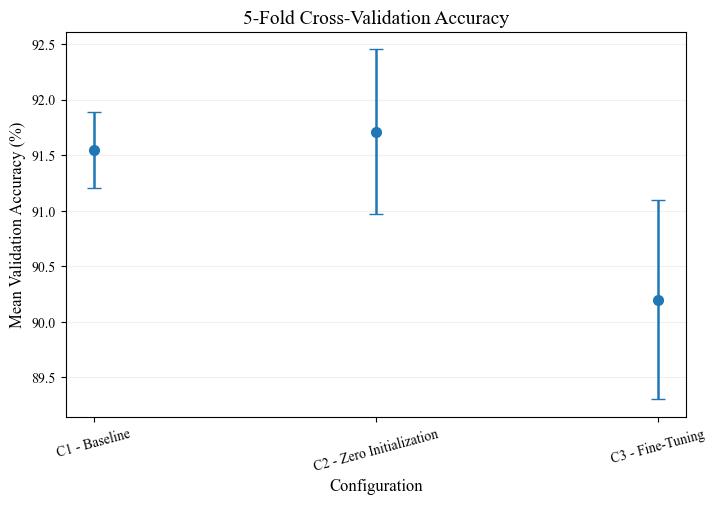

In [ ]:
# ============================================================
# CELL 58 — PLOT 13
# 5-FOLD CROSS-VALIDATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

x = np.arange(len(cv_summary))

plt.errorbar(
    x,
    cv_summary["Mean"],
    yerr=cv_summary["SD"],
    fmt="o",
    capsize=5,
    linewidth=1.8,
    markersize=7
)

plt.xticks(
    x,
    cv_summary["Configuration"],
    rotation=15
)

plt.xlabel("Configuration")
plt.ylabel("Mean Validation Accuracy (%)")

plt.title(
    "5-Fold Cross-Validation Accuracy"
)

plt.grid(
    alpha=0.2,
    axis="y"
)

save_figure(
    "plot_13_5_fold_cross_validation"
)

plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 59 — FINAL CONFIGURATION
# ============================================================

best_cv = cv_summary.loc[
    cv_summary["Mean"].idxmax()
]

print("FINAL CONFIGURATION")
print("=" * 50)

print(
    "Configuration:",
    best_cv["Configuration"]
)

print(
    f"Mean CV Accuracy: "
    f"{best_cv['Mean']:.2f}%"
)

print(
    f"Standard Deviation: "
    f"{best_cv['SD']:.2f}%"
)

print(
    f"Mean Training Time: "
    f"{best_cv['Mean Training Time (s)']:.2f} seconds"
)

FINAL CONFIGURATION
Configuration: C2 - Zero Initialization
Mean CV Accuracy: 91.71%
Standard Deviation: 0.74%
Mean Training Time: 106.37 seconds


In [ ]:
# ============================================================
# CELL 60 — FINAL MODEL
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Final configuration selected by 5-fold CV
# ------------------------------------------------------------

FINAL_INITIALIZATION = "zero"
FINAL_LEARNING_RATE = 0.001
FINAL_BATCH_SIZE = 32
FINAL_DROPOUT = 0.0


print("FINAL MODEL CONFIGURATION")
print("=" * 50)
print("Initialization :", FINAL_INITIALIZATION)
print("Optimizer      : RMSProp")
print("Learning Rate  :", FINAL_LEARNING_RATE)
print("Batch Size     :", FINAL_BATCH_SIZE)
print("Dropout        :", FINAL_DROPOUT)


# ------------------------------------------------------------
# Fresh pretrained MobileNetV2
# ------------------------------------------------------------

final_base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)


# Freeze pretrained base
final_base_model.trainable = False


# ------------------------------------------------------------
# Build final model
# ------------------------------------------------------------

inputs = keras.Input(
    shape=(224, 224, 3)
)

x = final_base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)


# Zero initialization selected by CV
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_initializer=keras.initializers.Zeros()
)(x)


final_model = keras.Model(
    inputs,
    outputs
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

final_model.compile(

    optimizer=keras.optimizers.RMSprop(
        learning_rate=FINAL_LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Model information
# ------------------------------------------------------------

print("\nTotal parameters:")
print(f"{final_model.count_params():,}")

print("\nTrainable parameters:")

trainable_params = np.sum([
    np.prod(v.shape)
    for v in final_model.trainable_variables
])

print(f"{trainable_params:,}")

FINAL MODEL CONFIGURATION
Initialization : zero
Optimizer      : RMSProp
Learning Rate  : 0.001
Batch Size     : 32
Dropout        : 0.0

Total parameters:
2,305,381

Trainable parameters:
47,397


In [ ]:
# ============================================================
# CELL 61 — TRAIN FINAL MODEL
# ============================================================

start_time = time.time()


final_history = final_model.fit(

    train_ds,

    epochs=EPOCHS,

    verbose=1
)


final_training_time = time.time() - start_time


print(
    f"\nFinal training time: "
    f"{final_training_time:.2f} seconds"
)


print(
    f"Final training accuracy: "
    f"{final_history.history['accuracy'][-1] * 100:.2f}%"
)


print(
    f"Final training loss: "
    f"{final_history.history['loss'][-1]:.4f}"
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.8067 - loss: 1.0204
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.9351 - loss: 0.2607
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9630 - loss: 0.1566
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9755 - loss: 0.1056
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.9837 - loss: 0.0767

Final training time: 84.32 seconds
Final training accuracy: 98.37%
Final training loss: 0.0767


In [ ]:
# ============================================================
# CELL 62 — FINAL TEST EVALUATION
# ============================================================

test_loss, test_accuracy = final_model.evaluate(
    test_ds,
    verbose=1
)


print("\nFINAL TEST RESULTS")
print("=" * 50)

print(
    f"Test Loss: "
    f"{test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 196ms/step - accuracy: 0.8997 - loss: 0.3092

FINAL TEST RESULTS
Test Loss: 0.3092
Test Accuracy: 89.97%


In [ ]:
# ============================================================
# CELL 63 — GET TEST PREDICTIONS AND TRUE LABELS
# ============================================================

import numpy as np


# ------------------------------------------------------------
# Get predictions from the test dataset
# ------------------------------------------------------------

predictions = final_model.predict(
    test_ds,
    verbose=1
)


# Convert probabilities to predicted class
y_pred = np.argmax(
    predictions,
    axis=1
)


# ------------------------------------------------------------
# Reconstruct true labels from test_raw
# ------------------------------------------------------------

y_true = np.array([
    label.numpy()
    for _, label in test_raw
])


# ------------------------------------------------------------
# Check that both match
# ------------------------------------------------------------

print(
    "Number of test samples:",
    len(y_true)
)

print(
    "Number of predictions:",
    len(y_pred)
)


if len(y_true) == len(y_pred):

    print("✓ Number of labels and predictions match.")

else:

    print("WARNING: Number of labels and predictions do not match!")

115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step
Number of test samples: 3669
Number of predictions: 3669
✓ Number of labels and predictions match.


In [ ]:
# ============================================================
# CELL 64 — PRECISION, RECALL AND F1 SCORE
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("FINAL TEST METRICS")
print("=" * 50)

print(
    f"Test Accuracy : {test_accuracy * 100:.2f}%"
)

print(
    f"Precision      : {precision * 100:.2f}%"
)

print(
    f"Recall         : {recall * 100:.2f}%"
)

print(
    f"F1 Score       : {f1 * 100:.2f}%"
)

FINAL TEST METRICS
Test Accuracy : 89.97%
Precision      : 90.54%
Recall         : 89.91%
F1 Score       : 89.93%


In [ ]:
# ============================================================
# CELL 65 — CLASSIFICATION REPORT
# ============================================================

# Get class names from TFDS information
try:

    class_names = dataset_info.features[
        "label"
    ].names

except:

    class_names = [
        str(i)
        for i in range(NUM_CLASSES)
    ]


report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    zero_division=0
)


print(report)


# ------------------------------------------------------------
# Save report
# ------------------------------------------------------------

report_path = os.path.join(
    OUTPUT_DIR,
    "final_classification_report.txt"
)


with open(
    report_path,
    "w"
) as f:

    f.write(report)


print(
    "\nClassification report saved to:"
)

print(report_path)

                            precision    recall  f1-score   support

                Abyssinian       0.88      0.86      0.87        98
          american_bulldog       0.66      0.93      0.78       100
 american_pit_bull_terrier       0.83      0.62      0.71       100
              basset_hound       0.94      0.92      0.93       100
                    beagle       0.92      0.91      0.91       100
                    Bengal       0.71      0.88      0.79       100
                    Birman       0.83      0.77      0.80       100
                    Bombay       0.90      0.89      0.89        88
                     boxer       0.93      0.79      0.85        99
         British_Shorthair       0.93      0.65      0.76       100
                 chihuahua       0.94      0.91      0.92       100
              Egyptian_Mau       0.94      0.77      0.85        97
    english_cocker_spaniel       0.99      0.91      0.95       100
            english_setter       0.93      0.96

Saved: outputs/plot_14_final_confusion_matrix.eps
Saved: outputs/plot_14_final_confusion_matrix.png


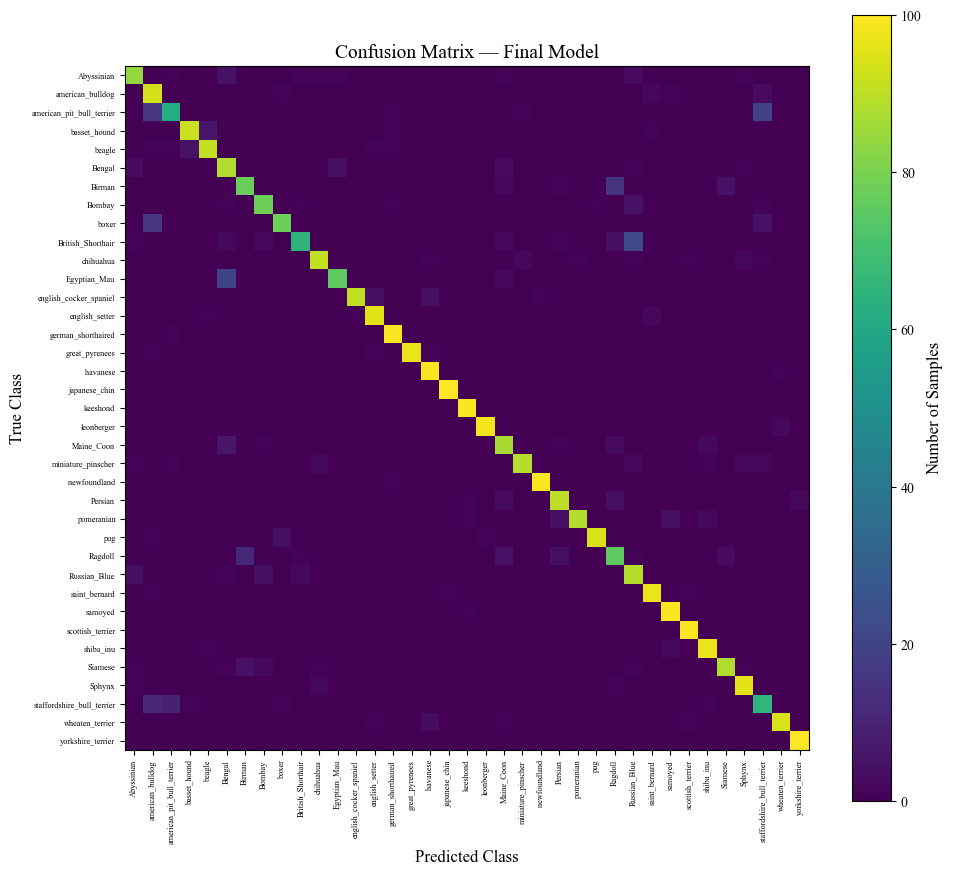

In [ ]:
# ============================================================
# CELL 66 — PLOT 14
# CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)


plt.figure(figsize=(10, 9))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix — Final Model"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.xticks(
    np.arange(NUM_CLASSES),
    class_names,
    rotation=90,
    fontsize=6
)

plt.yticks(
    np.arange(NUM_CLASSES),
    class_names,
    fontsize=6
)


plt.colorbar(
    label="Number of Samples"
)


plt.tight_layout()


save_figure(
    "plot_14_final_confusion_matrix"
)


plt.show()
plt.close()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# CELL 67 — SAVE FINAL RESULTS
# ============================================================

final_results = pd.DataFrame([{

    "Initialization":
        FINAL_INITIALIZATION,

    "Optimizer":
        "RMSProp",

    "Learning Rate":
        FINAL_LEARNING_RATE,

    "Batch Size":
        FINAL_BATCH_SIZE,

    "Dropout":
        FINAL_DROPOUT,

    "CV Mean Accuracy (%)":
        best_cv["Mean"],

    "CV SD (%)":
        best_cv["SD"],

    "Test Accuracy (%)":
        test_accuracy * 100,

    "Precision (%)":
        precision * 100,

    "Recall (%)":
        recall * 100,

    "F1 Score (%)":
        f1 * 100,

    "Training Time (s)":
        final_training_time,

    "Total Parameters":
        final_model.count_params(),

    "Trainable Parameters":
        int(trainable_params)

}])


display(final_results)


# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

final_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_model_results.csv"
    ),
    index=False
)


print(
    "\nFinal results saved to:"
)

print(
    os.path.join(
        OUTPUT_DIR,
        "final_model_results.csv"
    )
)

,Initialization,Optimizer,Learning Rate,Batch Size,Dropout,CV Mean Accuracy (%),CV SD (%),Test Accuracy (%),Precision (%),Recall (%),F1 Score (%),Training Time (s),Total Parameters,Trainable Parameters
0,zero,RMSProp,0.001,32,0.0,91.710526,0.741045,89.970016,90.536777,89.908525,89.925014,84.321741,2305381,47397



Final results saved to:
outputs/final_model_results.csv


In [ ]:
# ============================================================
# CELL 68 — ADDITIONAL EXERCISE CONFIGURATIONS
# ============================================================

additional_configs = {

    "C4 - Adam + Dropout":
    {
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 16,
        "dropout": 0.25,
        "fine_tuning": False
    },

    "C5 - Fine-Tuning":
    {
        "optimizer": "RMSProp",
        "learning_rate": 0.0001,
        "batch_size": 32,
        "dropout": 0.0,
        "fine_tuning": True
    }
}


for name, config in additional_configs.items():

    print(name)
    print(config)
    print()

C4 - Adam + Dropout
{'optimizer': 'Adam', 'learning_rate': 0.001, 'batch_size': 16, 'dropout': 0.25, 'fine_tuning': False}

C5 - Fine-Tuning
{'optimizer': 'RMSProp', 'learning_rate': 0.0001, 'batch_size': 32, 'dropout': 0.0, 'fine_tuning': True}



In [ ]:
# ============================================================
# CELL 69 — MODEL BUILDER FOR ADDITIONAL CV
# ============================================================

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


def build_additional_model(config):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )


    # --------------------------------------------------------
    # Feature extraction / fine-tuning
    # --------------------------------------------------------

    if config["fine_tuning"]:

        # Freeze most layers
        base_model.trainable = True

        # Keep earlier layers frozen
        for layer in base_model.layers[:-20]:
            layer.trainable = False

    else:

        # Completely frozen base
        base_model.trainable = False


    # --------------------------------------------------------
    # Classification head
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)


    # Dropout
    if config["dropout"] > 0:

        x = layers.Dropout(
            config["dropout"]
        )(x)


    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    if config["optimizer"] == "Adam":

        optimizer = keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        )

    else:

        optimizer = keras.optimizers.RMSprop(
            learning_rate=config["learning_rate"]
        )


    model.compile(

        optimizer=optimizer,

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    return model

In [ ]:
# ============================================================
# UPDATED make_dataset()
# ============================================================

def make_dataset(indices, batch_size=32, shuffle=False):

    # Convert indices to Tensor
    indices = tf.constant(
        indices,
        dtype=tf.int64
    )

    # Total number of samples
    total_samples = int(
        tf.data.experimental.cardinality(train_raw).numpy()
    )

    # --------------------------------------------------------
    # Create a boolean mask
    # --------------------------------------------------------

    mask = tf.scatter_nd(
        indices[:, tf.newaxis],
        tf.ones(
            tf.shape(indices),
            dtype=tf.bool
        ),
        [total_samples]
    )

    # --------------------------------------------------------
    # Add index to every sample
    # --------------------------------------------------------

    dataset = train_raw.enumerate()

    # --------------------------------------------------------
    # Keep only samples whose index belongs to this fold
    # --------------------------------------------------------

    dataset = dataset.filter(
        lambda index, data:
        tf.gather(mask, index)
    )

    # Remove the index
    dataset = dataset.map(
        lambda index, data: data,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # --------------------------------------------------------
    # Preprocess images
    # --------------------------------------------------------

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # --------------------------------------------------------
    # Shuffle training data
    # --------------------------------------------------------

    if shuffle:

        dataset = dataset.shuffle(
            buffer_size=512
        )

    # --------------------------------------------------------
    # Batch
    # --------------------------------------------------------

    dataset = dataset.batch(
        batch_size
    )

    # --------------------------------------------------------
    # Prefetch
    # --------------------------------------------------------

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [ ]:
# ============================================================
# CELL 70 — 5-FOLD CROSS-VALIDATION
# ADDITIONAL EXERCISE
# ============================================================

from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
import time
import gc
import tensorflow as tf


# ------------------------------------------------------------
# Number of training samples
# ------------------------------------------------------------

num_samples = int(
    tf.data.experimental.cardinality(train_raw).numpy()
)

print("Total training samples:", num_samples)


# ------------------------------------------------------------
# Create indices
# ------------------------------------------------------------

all_indices = np.arange(
    num_samples
)


# ------------------------------------------------------------
# 5-fold splitter
# ------------------------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


additional_cv_results = []


# ------------------------------------------------------------
# Run C4 and C5
# ------------------------------------------------------------

for config_name, config in additional_configs.items():

    print("\n")
    print("=" * 70)
    print(config_name)
    print("=" * 70)


    fold_number = 1


    for train_idx_fold, val_idx_fold in kf.split(
        all_indices
    ):

        print("\n" + "-" * 60)

        print(
            f"{config_name} | Fold {fold_number}/5"
        )

        print("-" * 60)


        # ----------------------------------------------------
        # Create training dataset
        # ----------------------------------------------------

        train_ds_fold = make_dataset(

            train_idx_fold,

            batch_size=config["batch_size"],

            shuffle=True
        )


        # ----------------------------------------------------
        # Create validation dataset
        # ----------------------------------------------------

        val_ds_fold = make_dataset(

            val_idx_fold,

            batch_size=config["batch_size"],

            shuffle=False
        )


        # ----------------------------------------------------
        # Build fresh model
        # ----------------------------------------------------

        model = build_additional_model(
            config
        )


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        start_time = time.time()


        history = model.fit(

            train_ds_fold,

            validation_data=val_ds_fold,

            epochs=EPOCHS,

            verbose=1
        )


        training_time = (
            time.time() - start_time
        )


        # ----------------------------------------------------
        # Best validation accuracy
        # ----------------------------------------------------

        best_val_accuracy = max(
            history.history["val_accuracy"]
        ) * 100


        # ----------------------------------------------------
        # Final validation accuracy
        # ----------------------------------------------------

        final_val_accuracy = (
            history.history["val_accuracy"][-1]
            * 100
        )


        # ----------------------------------------------------
        # Save result
        # ----------------------------------------------------

        additional_cv_results.append({

            "Configuration":
                config_name,

            "Fold":
                fold_number,

            "Optimizer":
                config["optimizer"],

            "Learning Rate":
                config["learning_rate"],

            "Batch Size":
                config["batch_size"],

            "Dropout":
                config["dropout"],

            "Fine-Tuning":
                config["fine_tuning"],

            "Best Validation Accuracy (%)":
                best_val_accuracy,

            "Final Validation Accuracy (%)":
                final_val_accuracy,

            "Training Time (s)":
                training_time
        })


        print(
            f"Best validation accuracy: "
            f"{best_val_accuracy:.2f}%"
        )

        print(
            f"Training time: "
            f"{training_time:.2f} seconds"
        )


        # ----------------------------------------------------
        # Clear memory
        # ----------------------------------------------------

        del model
        del train_ds_fold
        del val_ds_fold

        tf.keras.backend.clear_session()

        gc.collect()


        fold_number += 1


print("\n")
print("=" * 70)
print("ADDITIONAL CV RUNS COMPLETE")
print("=" * 70)

Total training samples: 2944


C4 - Adam + Dropout

------------------------------------------------------------
C4 - Adam + Dropout | Fold 1/5
------------------------------------------------------------
Epoch 1/5
    148/Unknown 39s 140ms/step - accuracy: 0.4348 - loss: 2.2839

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


148/148 ━━━━━━━━━━━━━━━━━━━━ 61s 289ms/step - accuracy: 0.6590 - loss: 1.3430 - val_accuracy: 0.8795 - val_loss: 0.4525
Epoch 2/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.9083 - loss: 0.3381 - val_accuracy: 0.8879 - val_loss: 0.3403
Epoch 3/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9465 - loss: 0.2130 - val_accuracy: 0.9032 - val_loss: 0.3082
Epoch 4/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9699 - loss: 0.1399 - val_accuracy: 0.8981 - val_loss: 0.2825
Epoch 5/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.9805 - loss: 0.1048 - val_accuracy: 0.9066 - val_loss: 0.2674
Best validation accuracy: 90.66%
Training time: 127.65 seconds

------------------------------------------------------------
C4 - Adam + Dropout | Fold 2/5
------------------------------------------------------------
Epoch 1/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 39s 185ms/step - accuracy: 0.6514 - loss: 1.3315 - val_accuracy: 0.8693 - val_loss: 0.4909
Epoch 2/5
148/148